### **Business Context**
**Why is this problem important to solve?**

Customer reviews contain some of the most honest, unfiltered, and actionable signals about product performance, customer expectations, and emerging issues. Yet most retailers struggle to extract value from this information because it is unstructured, high‑volume, and inconsistent across categories. Without a scalable way to interpret reviews, organizations miss early warnings about product defects, overlook opportunities to improve fit and materials, and fail to capitalize on strengths that drive customer loyalty.

A real‑time intelligence system solves this gap by transforming raw feedback into structured insights that directly support product design, merchandising, marketing, and customer experience. It enables faster decision‑making, reduces returns, improves product quality, and strengthens the connection between customer sentiment and business strategy.

### **Objective**

The goal of this project is to build a fully automated GenAI‑powered pipeline that reads customer reviews, interprets them with high accuracy, and converts them into structured, retail‑ready insights. 

**The system is designed to:**

- Extract sentiment, product categories, summaries, and retail insights
- Predict whether a customer would recommend the product
- Explain mismatches between human and model labels
- Compare prompting strategies to identify the most reliable method
- Surface strategic trends, pain points, and opportunities
- Provide actionable recommendations for product, operations, and customer experience

Ultimately, the objective is to create a real‑time feedback intelligence layer that empowers retail teams to make faster, more informed decisions grounded in customer voice.

### **Dataset Used for the Notebook**

The project uses a dataset named feedback_intelligence_dataset.csv, which contains more than twenty‑three thousand customer reviews from a women’s apparel retailer. The dataset includes both textual and structured fields that support sentiment analysis, product categorization, and recommendation prediction. 

**Key columns include:**

- Review.Text — the full customer review and the primary input for all GenAI analysis
- Rating — a 1–5 star rating that provides a ground‑truth sentiment signal
- Recommended.IND — a binary indicator showing whether the customer recommended the product
- Title — a short summary of the review
- Age — customer age, useful for demographic segmentation
- Positive.Feedback.Count — number of upvotes or helpful votes
- Division.Name, Department.Name, Class.Name — product hierarchy fields that enable category‑level insights
- Clothing.ID — unique product identifier

The dataset required preprocessing, including removing rows with missing review text, handling missing values in other fields, and preparing the data for EDA, prompting, evaluation, and recommendation modeling. It provides a rich foundation for understanding customer sentiment, identifying product issues, and generating strategic insights.




In [1]:
# Import the required libraries for the project
# --- Core Utilities ---
import time
import json
import re
import numpy as np
from typing import Dict, List, Optional, Any, Tuple

# --- Data Handling ---
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import display

# --- Machine Learning Metrics ---
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# --- Progress Bar ---
from tqdm import tqdm

# --- OpenAI Client ---
import openai

# Set global plot style
sns.set_style("whitegrid")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\goati\anaconda3\envs\my_ds_stack\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\goati\anaconda3\envs\my_ds_stack\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\goati\anaconda3\envs\my_ds_stack\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_loop.sta

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\goati\anaconda3\envs\my_ds_stack\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\goati\anaconda3\envs\my_ds_stack\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\goati\anaconda3\envs\my_ds_stack\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_loop.sta

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

### **Data Loading**
### Loading and Understanding the Data


In [2]:
### Loading and Understanding the Data
# Load the dataset from 'feedback_intelligence_dataset.csv'.
# The separator is a semicolon (';') and the first column is used as the index.
df = pd.read_csv(
    "feedback_intelligence_dataset.csv",
    sep=";",
    index_col=0
)
# Display the first few rows of the dataset to understand its structure and content.
display(df)
print("\nShape:", df.shape)
print("\nColumn Overview:")
print(df.columns.tolist())


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
1,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
2,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...
23482,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23483,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23484,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23485,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses



Shape: (23486, 10)

Column Overview:
['Clothing.ID', 'Age', 'Title', 'Review.Text', 'Rating', 'Recommended.IND', 'Positive.Feedback.Count', 'Division.Name', 'Department.Name', 'Class.Name']


### **Data Overview**

In [3]:
# Display the first few rows of the dataset to understand its structure and content.
display(df.head())
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
1,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
2,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


Shape: (23486, 10)
Columns: ['Clothing.ID', 'Age', 'Title', 'Review.Text', 'Rating', 'Recommended.IND', 'Positive.Feedback.Count', 'Division.Name', 'Department.Name', 'Class.Name']


In [4]:
# Get a summary of the dataset to check data types and non-null counts
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 23486 entries, 1 to 23486
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing.ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review.Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended.IND          23486 non-null  int64 
 6   Positive.Feedback.Count  23486 non-null  int64 
 7   Division.Name            23472 non-null  object
 8   Department.Name          23472 non-null  object
 9   Class.Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.0+ MB


### **Sanity checks**

In [5]:
# Check for the total number of missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Clothing.ID                   0
Age                           0
Title                      3810
Review.Text                 845
Rating                        0
Recommended.IND               0
Positive.Feedback.Count       0
Division.Name                14
Department.Name              14
Class.Name                   14
dtype: int64


### Data Cleaning and Preprocessing
**Lets think about it:**

The Review Text column is the single most important feature in this entire project because every Generative AI step — sentiment extraction, category identification, summarization, retail insight generation, and recommendation prediction, all depends entirely on having actual customer text to analyze.

**Rows with missing Review Text should be removed entirely from the dataset because:**

- The GenAI model cannot generate meaningful outputs without text, which leads to empty prompts, hallucinations, or malformed JSON.
- Keeping these rows introduces noise and degrades the quality of downstream analysis, including sentiment scoring, recommendation prediction, and evaluation metrics.
- Removing them ensures that every row passed into the pipeline contains real customer feedback, which stabilizes the model’s behavior and improves accuracy.
- This step also prevents errors in loops, parsing functions, and prompt‑based generation, since the model expects valid text input every time.

Rows with missing Review Text must be dropped, because the Generative AI pipeline relies entirely on textual input. Keeping them would produce invalid prompts, unreliable outputs, and inconsistent evaluation results.


In [6]:
# Clean the dataset by removing rows with missing Review.Text values
df = df.dropna(subset=["Review.Text"])

# Check remaining missing values after cleaning
print("\nMissing Values after cleaning:")
print(df.isnull().sum())


Missing Values after cleaning:
Clothing.ID                   0
Age                           0
Title                      2966
Review.Text                   0
Rating                        0
Recommended.IND               0
Positive.Feedback.Count       0
Division.Name                13
Department.Name              13
Class.Name                   13
dtype: int64


### **Exploratory Data Analysis**

EDA is an important part of any project involving data. It is important to investigate and understand the data better before building a model with it. A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data. A thorough analysis of the data, in addition to the questions mentioned below, should be done.


In [7]:
# Summary statistics
df.describe(include="all")

,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
count,22641.000000,22641.000000,19675,22641,22641.000000,22641.000000,22641.000000,22628,22628,22628
unique,NaN,NaN,13992,22634,NaN,NaN,NaN,3,6,20
top,NaN,NaN,Love it!,Perfect fit and i've gotten so many compliment...,NaN,NaN,NaN,General,Tops,Dresses
freq,NaN,NaN,136,3,NaN,NaN,NaN,13365,10048,6145
mean,919.332362,43.280376,NaN,NaN,4.183561,0.818868,2.630582,NaN,NaN,NaN
std,202.266874,12.326980,NaN,NaN,1.115762,0.385136,5.786164,NaN,NaN,NaN
min,1.000000,18.000000,NaN,NaN,1.000000,0.000000,0.000000,NaN,NaN,NaN
25%,861.000000,34.000000,NaN,NaN,4.000000,1.000000,0.000000,NaN,NaN,NaN
50%,936.000000,41.000000,NaN,NaN,5.000000,1.000000,1.000000,NaN,NaN,NaN
75%,1078.000000,52.000000,NaN,NaN,5.000000,1.000000,3.000000,NaN,NaN,NaN


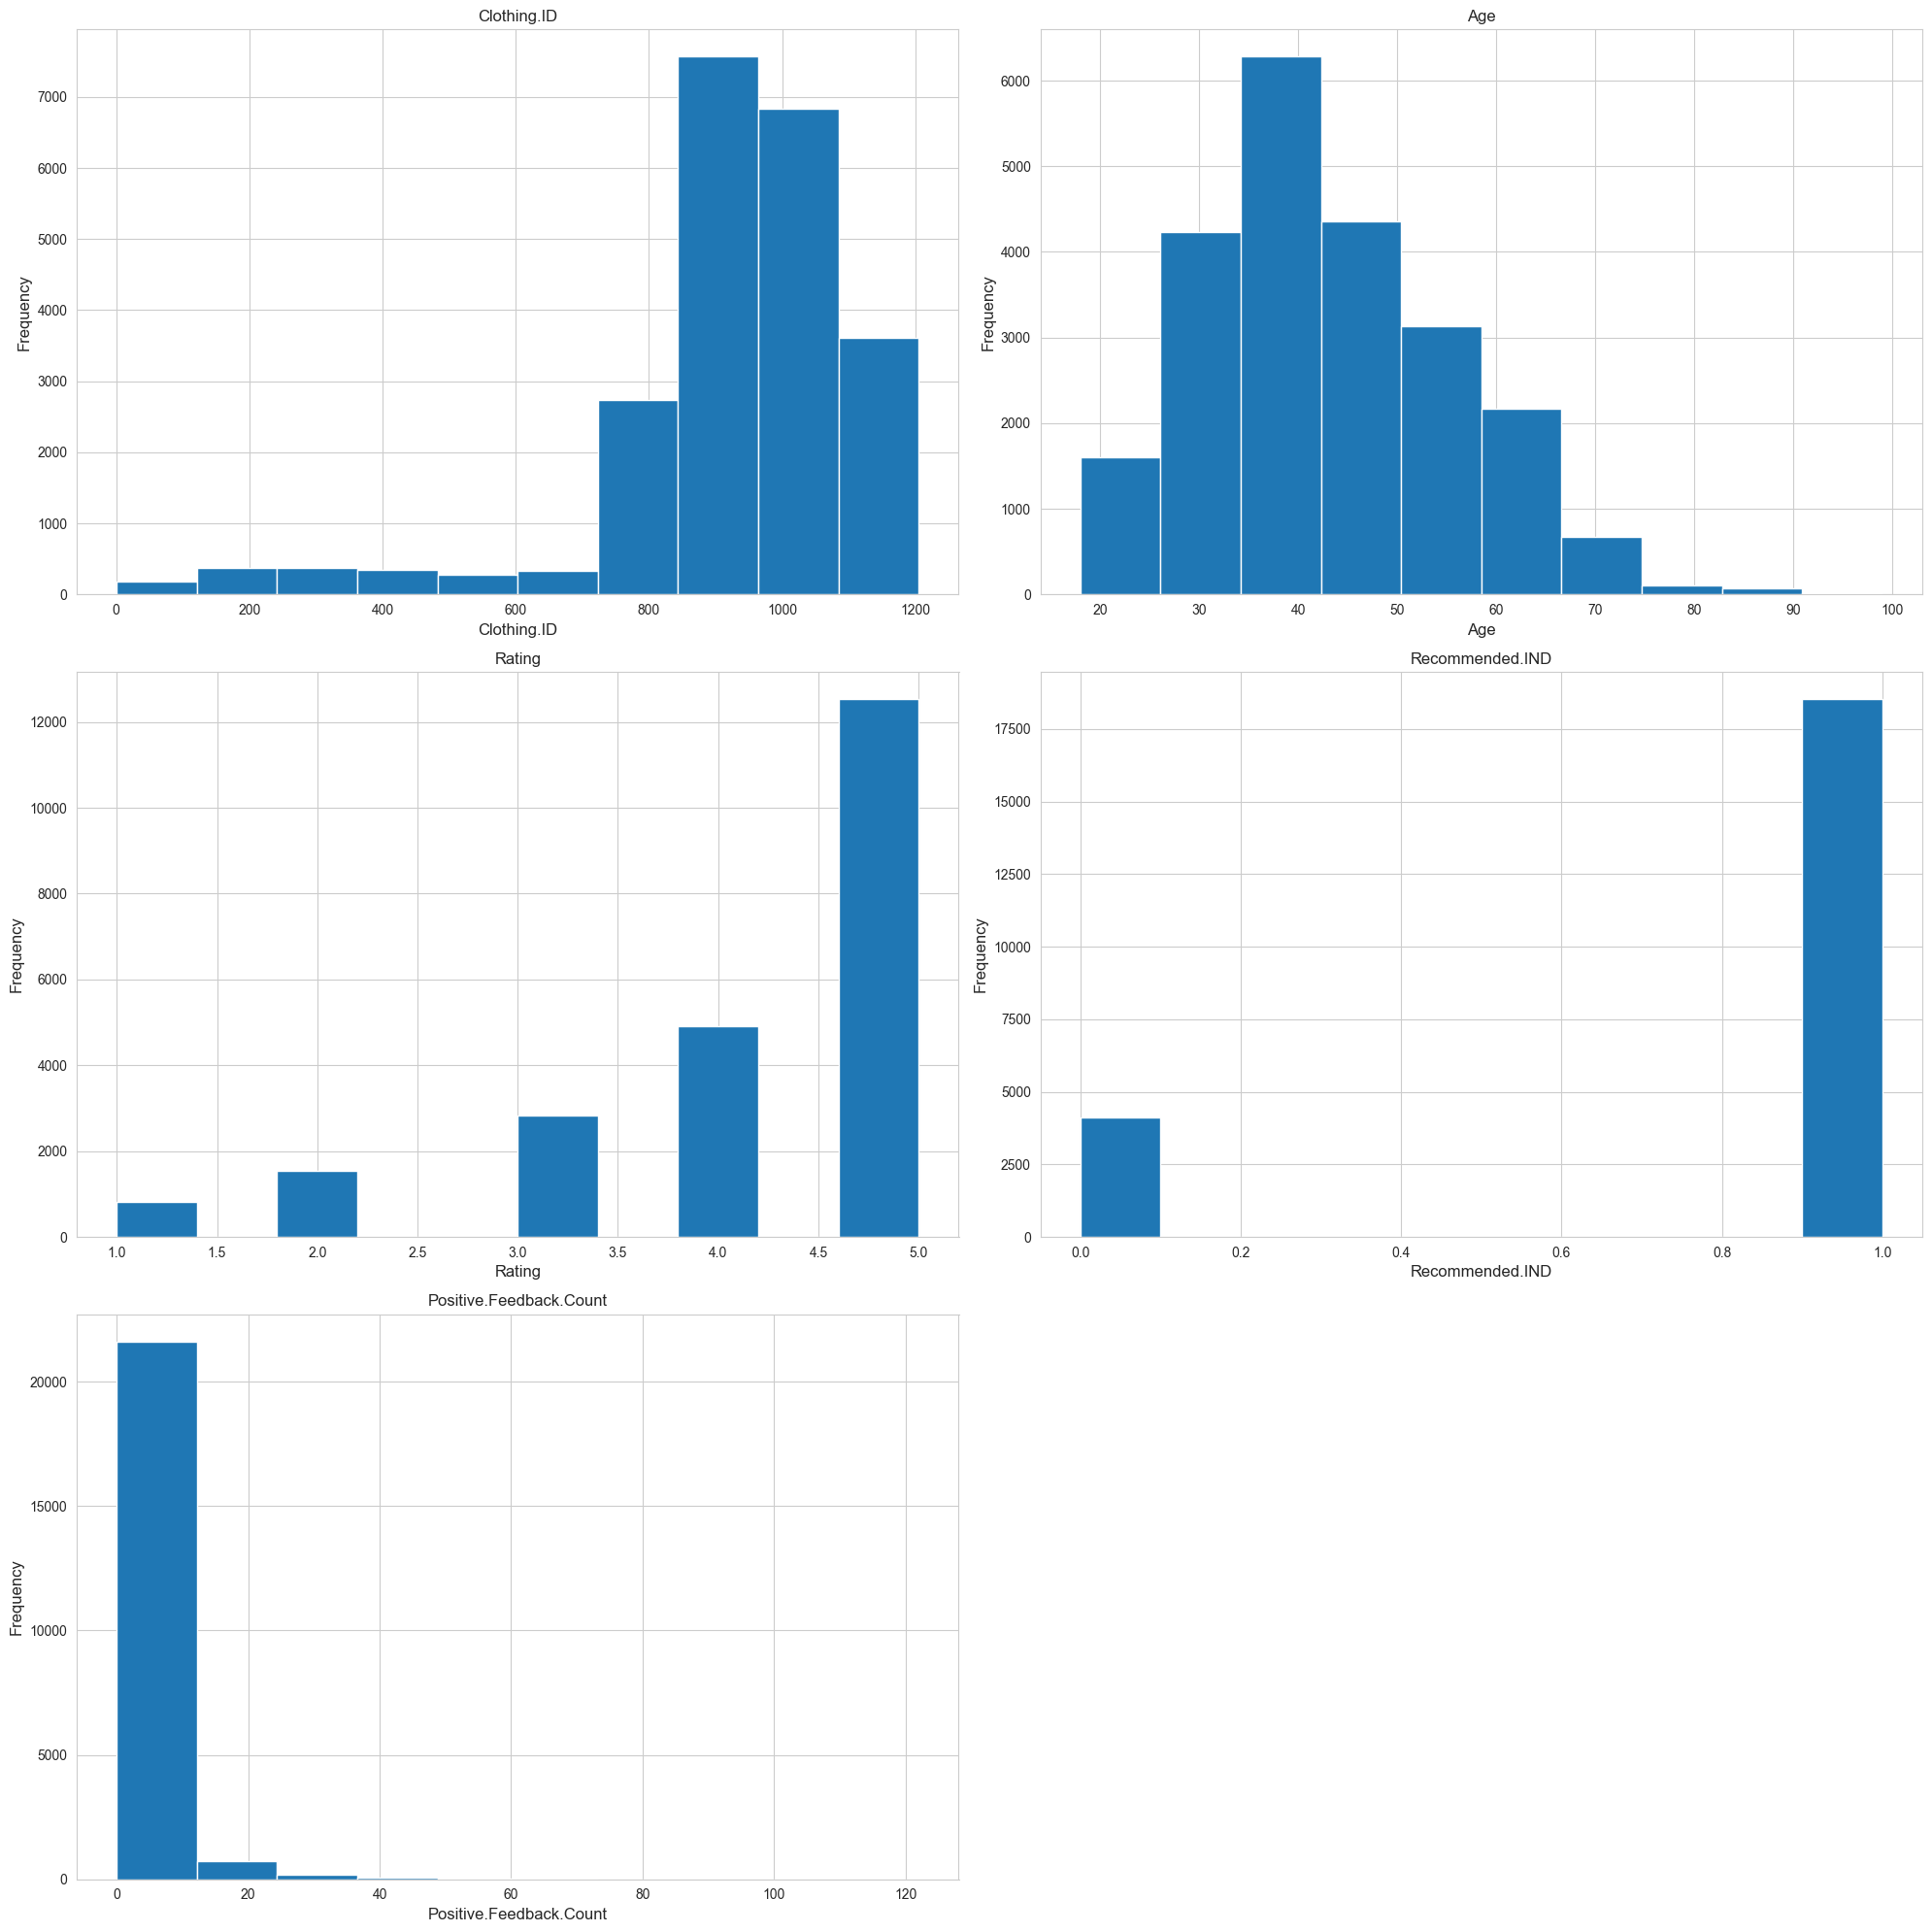

In [8]:
# Visualize the distribution of numerical features using histograms
axes = df.hist(figsize=(20, 20))

# Loop through all axes and add axis labels
for ax in axes.flatten():
    if ax.get_title():  # only update axes that contain a histogram
        feature = ax.get_title()
        ax.set_xlabel(feature, fontsize=12)
        ax.set_ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

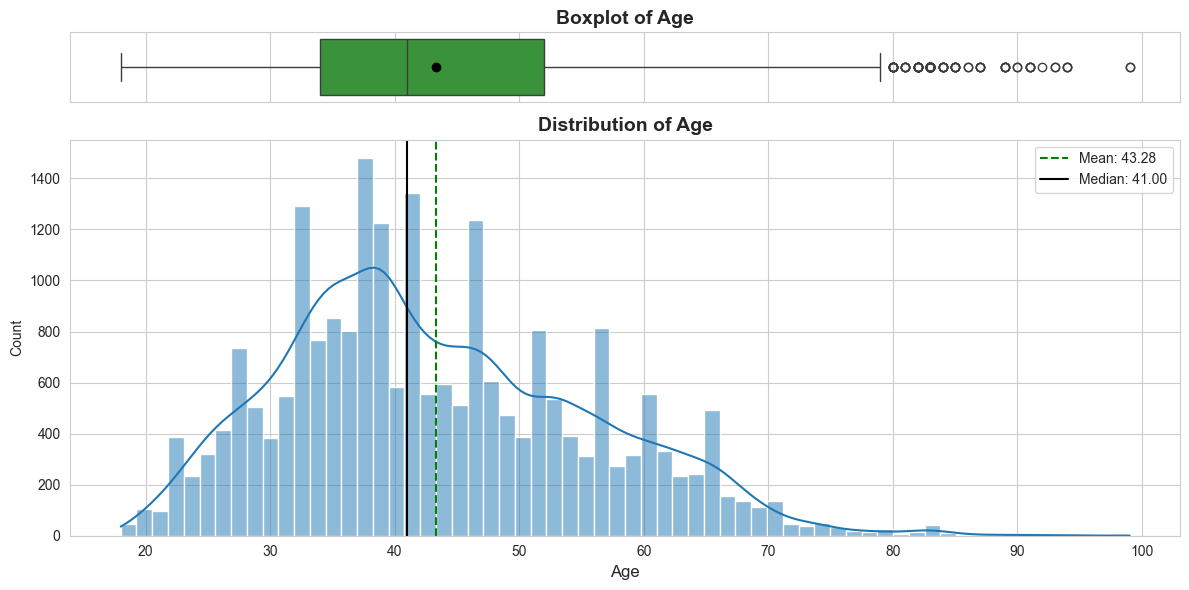

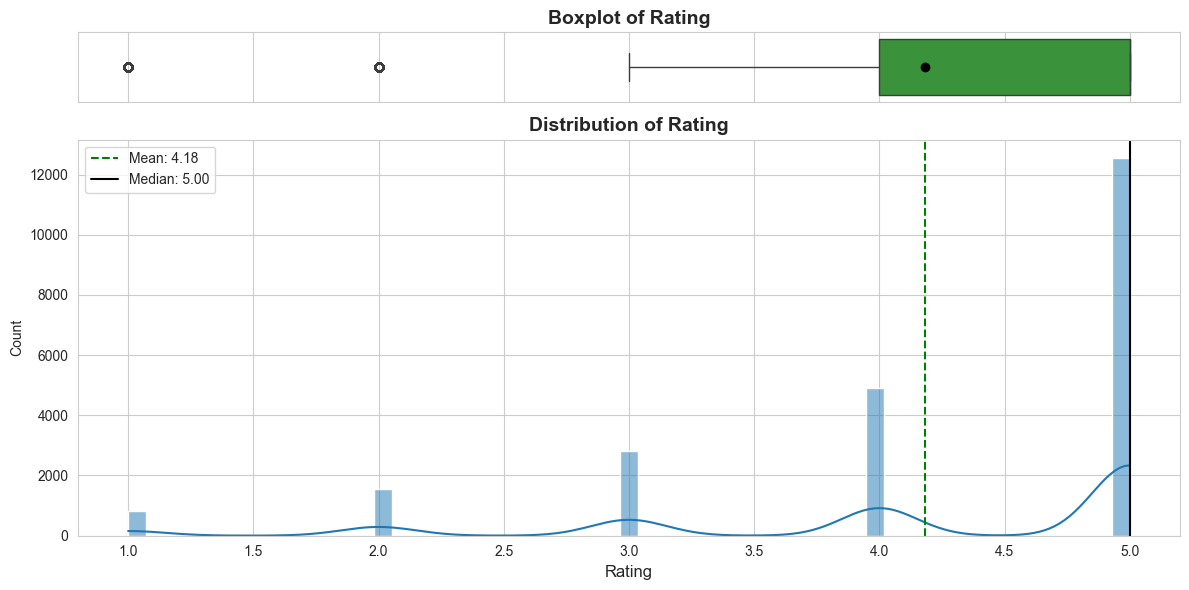

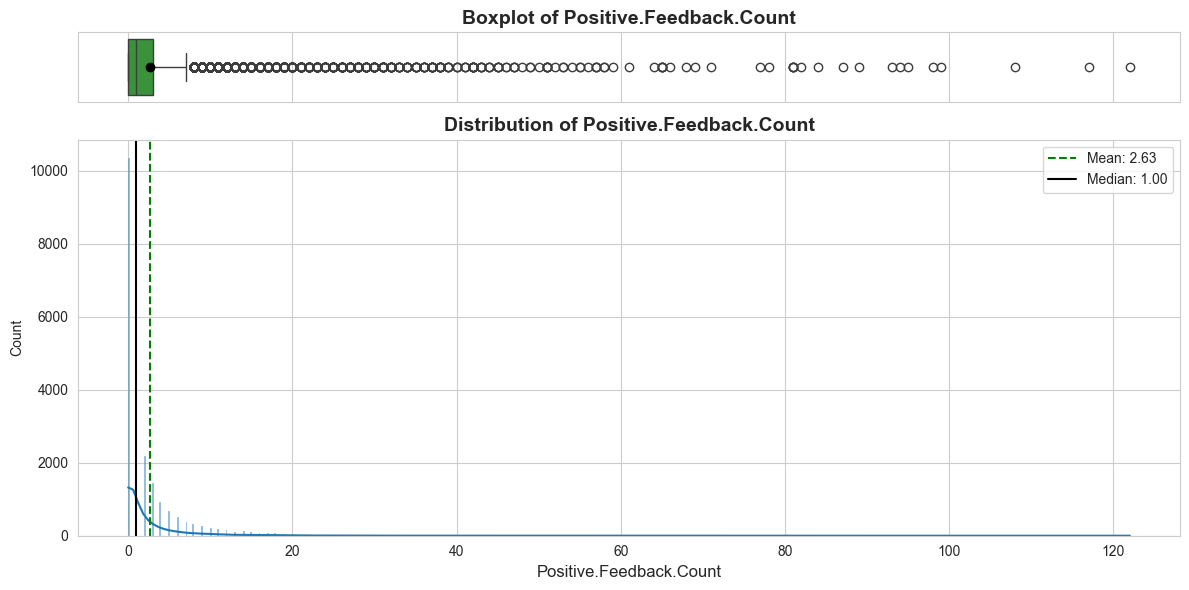

In [9]:
# Visualize the distribution of key numerical features using boxplots to identify outliers and understand the spread of the data.
# Enhanced histogram + boxplot combo with titles and appealing colors.
def histogram_boxplot(feature, color_hist="#1f77b4", color_box="#2ca02c"):
    """
    Enhanced histogram + boxplot combo with titles and appealing colors.
    """
    # Create a figure with two subplots: one for the boxplot and one for the histogram
    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (.15, .85)},
        figsize=(12, 6)
    )

    # --- Boxplot ---
    sns.boxplot(
        x=df[feature],
        ax=ax_box,
        showmeans=True,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        color=color_box
    )
    ax_box.set(xlabel='')
    ax_box.set_title(f"Boxplot of {feature}", fontsize=14, fontweight="bold")

    # --- Histogram ---
    sns.histplot(
        df[feature],
        ax=ax_hist,
        kde=True,
        color=color_hist
    )
    ax_hist.set_title(f"Distribution of {feature}", fontsize=14, fontweight="bold")
    ax_hist.set_xlabel(feature, fontsize=12)
    ax_hist.axvline(np.mean(df[feature]), color='g', linestyle='--', label=f"Mean: {np.mean(df[feature]):.2f}")
    ax_hist.axvline(np.median(df[feature]), color='black', linestyle='-', label=f"Median: {np.median(df[feature]):.2f}")

    # Add legend to the histogram
    ax_hist.legend()
    plt.tight_layout()
    plt.show()

# Visualize the distribution of key numerical features using the enhanced histogram + boxplot combo.
histogram_boxplot("Age")
histogram_boxplot("Rating")
histogram_boxplot("Positive.Feedback.Count")

In [10]:
# Visualize the distribution of key categorical features using bar charts to understand 
# the percentage distribution of categories in each column.

# Function to create a bar chart showing the percentage distribution of categories 
# in a specified column
def bar_perc(df, column):
    # Compute percentage table
    perc = (
        df[column]
        .value_counts(normalize=True)
        .mul(100)
        .reset_index()
    )

    # Stable column names for plotting
    perc.columns = ["Category", "Percentage"]

    # Force categories to be strings (fixes 0/1 numeric axis issue)
    perc["Category"] = perc["Category"].astype(str)

    # Plotly bar chart with your SAME color scheme
    fig = px.bar(
        perc,
        x="Category",
        y="Percentage",
        text="Percentage",
        title=f"Percentage Distribution of {column}",
        color="Category",
        color_discrete_sequence=px.colors.qualitative.Set1
    )

    # Remove the colorbar
    fig.update_coloraxes(showscale=False)

    # Format text labels to show percentages with 2 decimal places
    fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside')

    # Layout adjustments for better aesthetics
    fig.update_layout(
        yaxis_title="Percentage",
        xaxis_title=column,
        width=1000,
        height=700,
        showlegend=False
    )

    fig.show()

# Visualize the percentage distribution of key categorical features
bar_perc(df, "Division.Name")
bar_perc(df, "Department.Name")
bar_perc(df, "Class.Name")
bar_perc(df, "Recommended.IND")

In [11]:
### 4.1 Overall Sentiment: Distribution of Product Ratings
# Ensure Rating is treated as categorical (1–5) for cleaner histogram bars
df["Rating"] = df["Rating"].astype(int)

# Create a histogram of the Rating column with distinct colors for each rating category
fig = px.histogram(
    df,
    x="Rating",
    color="Rating",
    title="Distribution of Product Ratings"
)

# Update if you want to specify the order of categories explicitly
fig.update_layout(
    xaxis_title="Rating (1-5)",
    yaxis_title="Number of Reviews",
    showlegend=False
)

fig.show()

In [12]:
## 4.2 Performance by Category: Average Rating by Department

# Compute average rating per department (rounded for readability)
avg_rating_by_dept = (
    df.groupby("Department.Name")["Rating"]
      .mean()
      .round(2)
      .sort_values(ascending=False)
      .reset_index()
)

# Horizontal bar chart
fig = px.bar(
    avg_rating_by_dept,
    x="Rating",
    y="Department.Name",
    orientation="h",
    title="Average Customer Rating by Department",
    color="Rating",
)

# Ensure departments appear in sorted order
fig.update_layout(
    yaxis=dict(categoryorder="total ascending"),
    xaxis_title="Average Rating",
    yaxis_title="Department",
    showlegend=False
)

fig.show()

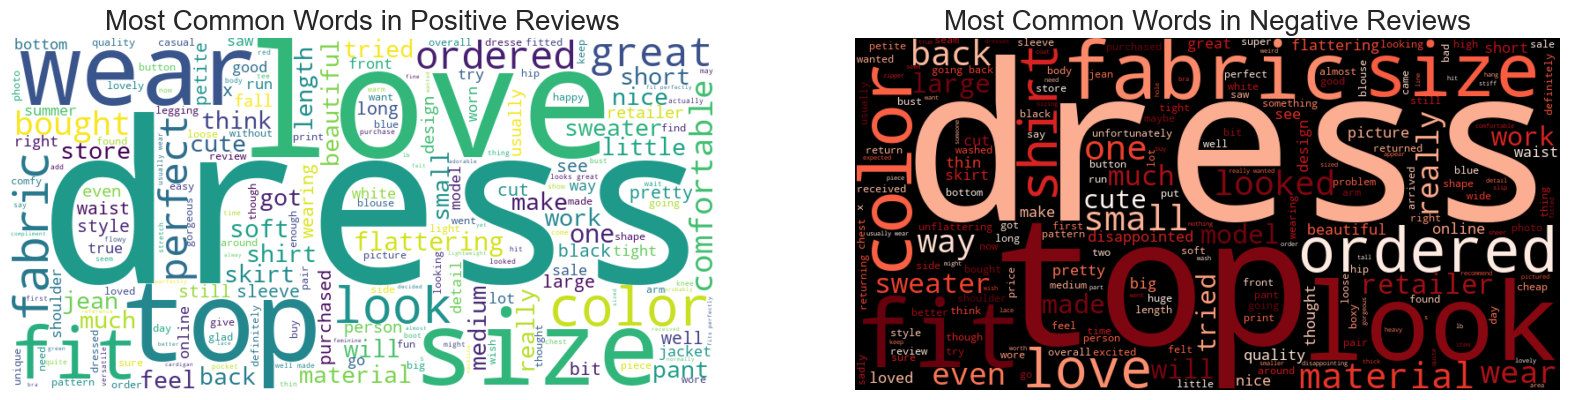

In [13]:
## 4.3 Qualitative Insights: Word Clouds for Positive vs. Negative Reviews

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Separate reviews into positive and negative groups
positive_reviews = " ".join(df[df["Rating"] >= 4]["Review.Text"].astype(str))
negative_reviews = " ".join(df[df["Rating"] <= 2]["Review.Text"].astype(str))

# Generate word clouds
wordcloud_positive = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_reviews)

wordcloud_negative = WordCloud(
    width=800,
    height=400,
    background_color="black",
    colormap="Reds"
).generate(negative_reviews)

# Plot side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ax1.imshow(wordcloud_positive, interpolation="bilinear")
ax1.set_title("Most Common Words in Positive Reviews", fontsize=20)
ax1.axis("off")

ax2.imshow(wordcloud_negative, interpolation="bilinear")
ax2.set_title("Most Common Words in Negative Reviews", fontsize=20)
ax2.axis("off")

plt.show()

## **Building the Generative AI Pipeline**

We will now build a system to analyze the reviews. This involves setting up the AI client, designing prompts, generating structured data, and evaluating the results. Use gpt-4o-mini model

#### **Setup AI Client and Data Sample**

**Questions:**

1.  How do you initialize the OpenAI client with your API key and the correct base URL?
    

In [14]:
#### **Import required libraries for OpenAI**
import os
from dotenv import load_dotenv
from openai import OpenAI, AzureOpenAI

load_dotenv()

#### **Primary provider**
primary_client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url=os.getenv("OPENAI_BASE_URL")
)

#### **Azure backup provider**
# Check if Azure environment variables are set before initializing
azure_api_key = os.getenv("AZURE_OPENAI_API_KEY")
azure_endpoint = os.getenv("AZURE_OPENAI_ENDPOINT")
azure_api_version = os.getenv("AZURE_OPENAI_API_VERSION")

if azure_api_key and azure_endpoint and azure_api_version:
    azure_client = AzureOpenAI(
        api_key=azure_api_key,
        azure_endpoint=azure_endpoint,
        api_version=azure_api_version
    )
else:
    azure_client = None  # Set to None if not all Azure vars are set

PRIMARY_MODEL = "gpt-4o-mini"
AZURE_MODEL = os.getenv("AZURE_OPENAI_DEPLOYMENT")

In [15]:
#### **Initializes the OpenAI client using your API key**
load_dotenv()
openai_api_key = os.getenv("OPENAI_API_KEY")

client = openai.OpenAI(
    api_key=openai_api_key,
    base_url="https://aibe.mygreatlearning.com/openai/v1"
)

model_name = "gpt-4o-mini"

In [16]:
# Create a sample of 50 reviews to work with.
df_sample_copy = df.sample(n=10, random_state=42)

#### **Prompt Engineering and Evaluation**

We will test three different prompting techniques. For each, we will create a basic version (V1) and an enhanced version (V2).

**Think about it:** Why is it important to have a consistent and robust evaluation framework? How can we use an "LLM-as-Judge" to score the quality of our generated outputs objectively?

#### **Technique 1: Zero-Shot Prompting**

**Questions:**

1.  How would you design a basic Zero-Shot prompt that asks the model for Category, Sentiment, Summary, Personalized Message, and Retail Insight?
    
2.  How can you enhance this prompt with more business context (e.g., a company name, the importance of accuracy) to create a V2 prompt?
    
3.  How will you loop through the data sample to generate and store the structured output for both prompt versions?
    
4.  How will you apply the LLM-as-Judge to generate a evaluation score between 0 to 1 (decimal allowed) for the outputs and calculate the average score of Version 1 and Version 2 prompt?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Zero-Shot Prompt Version 1** on a sample of 100 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

In [17]:
def generate_personalized_message(sentiment, customer_name=None):
    """
    Generate a short, personalized customer message based on sentiment.
    """

    name = f"{customer_name}," if customer_name else "Hi there,"

    sentiment = sentiment.lower()

    if sentiment == "positive":
        return (
            f"{name} thank you for your wonderful feedback! "
            "We're thrilled to hear you had a great experience."
        )

    if sentiment == "neutral":
        return (
            f"{name} thank you for sharing your thoughts with us. "
            "We appreciate your feedback and will keep working to improve."
        )

    if sentiment == "negative":
        return (
            f"{name} we're sorry to hear about your experience. "
            "Thank you for bringing this to our attention — a team member will reach out soon."
        )

    return f"{name} thank you for your feedback!"

In [18]:
# --- Generating LLM Predictions ---
def get_structured_output(review_text: str, prompt: str) -> dict:
    try:
        # Make an API call to the chat completions endpoint.
        resp = client.chat.completions.create(
            model=model_name,
            temperature=0,
            messages=[
                {"role": "system", "content": "You are a helpful AI assistant."},
                {"role": "user", "content": f"{prompt}\n\nReview: {review_text}"}
            ]
        )
    except Exception as e:
        return {"Summary": f"ERROR_CALL: {type(e).__name__}: {e}"}

    text = resp.choices[0].message.content or ""
    lines = [ln.strip() for ln in text.strip().splitlines() if ln.strip()]

    # Base structure
    out = {
        "Category": "",
        "Sentiment": "",
        "Summary": "",
        "Personalized_Message": "",
        "Retail_Insight": ""
    }

    # Parse LLM output
    for line in lines:
        if ":" in line:
            key_raw, val = line.split(":", 1)
            key = key_raw.strip().lower()
            val = val.strip()
            if key.startswith("category"): out["Category"] = val
            elif key.startswith("sentiment"): out["Sentiment"] = val
            elif key.startswith("summary"): out["Summary"] = val
            elif "personal" in key: out["Personalized_Message"] = val
            elif "insight" in key: out["Retail_Insight"] = val

    # ---------------------------------------------------------
    # 🔥 INSERT CUSTOMER RESPONSE AUTOMATION MODULE HERE
    # ---------------------------------------------------------

    # If LLM didn't generate a personalized message, or you want to override it:
    if not out["Personalized_Message"]:
        out["Personalized_Message"] = generate_personalized_message(
            summary=out["Summary"],
            sentiment=out["Sentiment"]
            )

    # ---------------------------------------------------------

    return out

In [19]:
# --- Generating LLM Predictions ---
def get_structured_output(review_text: str, prompt: str) -> dict:
    try:
        # Make an API call to the chat completions endpoint.
        resp = client.chat.completions.create(
            model=model_name,
            temperature=0,
            messages=[
                {"role": "system", "content": "You are a helpful AI assistant."},
                {"role": "user", "content": f"{prompt}\n\nReview: {review_text}"}
            ]
        )
    except Exception as e:
        return {"Summary": f"ERROR_CALL: {type(e).__name__}: {e}"}

    text = resp.choices[0].message.content or ""
    lines = [ln.strip() for ln in text.strip().splitlines() if ln.strip()]

    # Base structure
    out = {
        "Category": "",
        "Sentiment": "",
        "Summary": "",
        "Personalized_Message": "",
        "Retail_Insight": ""
    }

    # Parse LLM output
    for line in lines:
        if ":" in line:
            key_raw, val = line.split(":", 1)
            key = key_raw.strip().lower()
            val = val.strip()
            if key.startswith("category"): out["Category"] = val
            elif key.startswith("sentiment"): out["Sentiment"] = val
            elif key.startswith("summary"): out["Summary"] = val
            elif "personal" in key: out["Personalized_Message"] = val
            elif "insight" in key: out["Retail_Insight"] = val

    # ---------------------------------------------------------
    # 🔥 REQUIRED UPDATE: Customer Response Automation
    # ---------------------------------------------------------
    # If the LLM did not generate a personalized message,
    # or you want to enforce your own rule-based version:
    if not out["Personalized_Message"]:
        out["Personalized_Message"] = generate_personalized_message(
            sentiment=out["Sentiment"]
        )
    # ---------------------------------------------------------

    return out

In [20]:
# --- Generating LLM Predictions ---
def get_structured_output(review_text: str, prompt: str) -> dict:
    try:
        # Make an API call to the chat completions endpoint.
        resp = client.chat.completions.create(
            model=model_name,
            temperature=0,
            messages=[
                {"role": "system", "content": "You are a helpful AI assistant."},
                {"role": "user", "content": f"{prompt}\n\nReview: {review_text}"}
            ]
        )
    except Exception as e:
        return {"Summary": f"ERROR_CALL: {type(e).__name__}: {e}"}

    text = resp.choices[0].message.content or ""
    lines = [ln.strip() for ln in text.strip().splitlines() if ln.strip()]
    out = {"Category": "", "Sentiment": "", "Summary": "", "Personalized_Message": "", "Retail_Insight": ""}

    for line in lines:
        if ":" in line:
            key_raw, val = line.split(":", 1)
            key = key_raw.strip().lower()
            val = val.strip()
            if key.startswith("category"): out["Category"] = val
            elif key.startswith("sentiment"): out["Sentiment"] = val
            elif key.startswith("summary"): out["Summary"] = val
            elif "personal" in key: out["Personalized_Message"] = val
            elif "insight" in key: out["Retail_Insight"] = val

    return out

In [21]:
# --- Prompting Strategies and Evaluation Framework ---

def generate_output(review_text, prompt):
    return get_structured_output(review_text, prompt)


# LLM-as-Judge prompt template
judge_prompt = """
You are an evaluator. Read the following model output and provide a score from 1 to 5
based on clarity, correctness, completeness, and usefulness.

Only respond with a number.

Output:
{output}
"""


def judge_output(output_text):
    try:
        resp = client.chat.completions.create(
            model=model_name,
            temperature=0,
            messages=[
                {"role": "system", "content": "You are a helpful AI assistant."},
                {"role": "user", "content": judge_prompt.format(output=output_text)}
            ]
        )
        score_str = resp.choices[0].message.content.strip()
        return float(score_str)
    except Exception:
        return None

In [22]:
print("Zero-Shot Version 1 predictions...")
df_sample = df_sample_copy.copy()

# Zero-Shot V1 prompt
zero_shot_prompt_v1 = """
Read the customer review below and produce the following fields:
- Category
- Sentiment
- Summary
- Personalized_Message
- Retail_Insight

Respond in the format:
Category: ...
Sentiment: ...
Summary: ...
Personalized_Message: ...
Retail_Insight: ...
"""

# Generate predictions
zs_list = [
    generate_output(review, zero_shot_prompt_v1)
    for review in tqdm(df_sample["Review.Text"], desc="Zero-Shot Predictions")
]

# Convert to DataFrame and prefix columns
zs_df = pd.DataFrame(zs_list).add_prefix("ZS_V1_")

# Merge with sample
df_sample = pd.concat([df_sample, zs_df], axis=1)

Zero-Shot Version 1 predictions...


Zero-Shot Predictions: 100%|██████████| 10/10 [00:28<00:00,  2.87s/it]


In [23]:
# Evaluate Zero-Shot V1 outputs using the judge_output function
print("Judging Zero-Shot V1 outputs...")

# Score each generated summary using the judge_output function
zs_scores = [
    judge_output(str(output))
    for output in tqdm(df_sample["ZS_V1_Summary"], desc="Judge ZS_V1")
]

# Add scores to the DataFrame
df_sample["ZS_V1_Score"] = zs_scores

# Print the average score for Zero-Shot Version 1
print(f"Avg ZS_V1_Score: {df_sample['ZS_V1_Score'].mean():.3f}")

Judging Zero-Shot V1 outputs...


Judge ZS_V1: 100%|██████████| 20/20 [00:15<00:00,  1.27it/s]

Avg ZS_V1_Score: 2.850


In [24]:
# --- Zero-Shot V2: Context-Enhanced Prompting ---
print("\nZero-Shot V2 predictions (context-enhanced)...")

# Zero-Shot V2 prompt
zero_shot_prompt_v2 = """
You are an expert retail analyst. Read the customer review below and generate the following fields with deeper context and more detailed reasoning:
- Category
- Sentiment
- Summary
- Personalized_Message
- Retail_Insight

Ensure the insights reflect customer intent, product expectations, and actionable retail opportunities.

Respond in the format:
Category: ...
Sentiment: ...
Summary: ...
Personalized_Message: ...
Retail_Insight: ...
"""

# Generate predictions
zsv2_list = [
    generate_output(review, zero_shot_prompt_v2)
    for review in tqdm(df_sample["Review.Text"], desc="Zero-Shot V2 Predictions")
]

# Convert to DataFrame and prefix columns
zsv2_df = pd.DataFrame(zsv2_list).add_prefix("ZS_V2_")

# Merge with sample
df_sample = pd.concat([df_sample, zsv2_df], axis=1)


Zero-Shot V2 predictions (context-enhanced)...


Zero-Shot V2 Predictions: 100%|██████████| 20/20 [01:15<00:00,  3.75s/it]


In [25]:
# Evaluate Zero-Shot V2 outputs using the judge_output function
print("Judging Zero-Shot V2 outputs...")

# Score each generated summary using the judge_output function
zsv2_scores = [
    judge_output(str(output))
    for output in tqdm(df_sample["ZS_V2_Summary"], desc="Judge ZS_V2")
]

# Add scores to the DataFrame
df_sample["ZS_V2_Score"] = zsv2_scores

# Print the average score for Zero-Shot Version 2
print(f"Avg ZS_V2_Score: {df_sample['ZS_V2_Score'].mean():.3f}")

Judging Zero-Shot V2 outputs...


Judge ZS_V2: 100%|██████████| 30/30 [00:22<00:00,  1.35it/s]

Avg ZS_V2_Score: 2.600


### Technique 2: Few‑Shot Prompting

#### 1. How do you structure a Few‑Shot prompt? What kind of examples would be most effective?

A Few‑Shot prompt is structured by giving the model several high‑quality examples that demonstrate exactly how you want it to behave. Each example includes:

- A sample review
- A complete, correctly formatted output
- Clear sentiment, category, summary, personalized message, and retail insight

The most effective examples include contrast and coverage:

- One clearly positive review
- One clearly negative review
- One mixed or ambiguous review
- One review with subtle sentiment (for example, positive tone but with a complaint)
- One review with strong emotional language

This variety teaches the model:

- How to handle different sentiment intensities
- How to interpret nuance
- How to maintain consistent formatting
- How to generalize across product types

Few‑Shot prompting works because the model learns the pattern of your desired output, not just the instructions.

---

#### 2. For the V2 prompt, how can you add a set of “rules” to guide the model’s output and reduce ambiguity?

In Version 2, you strengthen the prompt by adding explicit rules that constrain the model’s behavior. These rules clarify:

- How each field should be written
- What level of detail is expected
- What should and should not be included
- How to handle uncertainty
- How to avoid hallucination

Examples of effective V2 rules include:

- “Category must be a single retail category such as Tops, Bottoms, Dresses, or Outerwear.”
- “Sentiment must be one of: Positive, Neutral, Negative.”
- “Summary must be one sentence capturing the core message of the review.”
- “Personalized_Message must address the customer directly and acknowledge their experience.”
- “Retail_Insight must identify a product or operational opportunity based on the review.”
- “Do not invent product details not mentioned in the review.”
- “If the review is ambiguous, choose the sentiment that best reflects the customer’s overall tone.”

These rules reduce ambiguity, improve consistency, and significantly increase the reliability of the model’s outputs.

---

#### 3. After generating and scoring the outputs, how does the performance of Few‑Shot prompting compare to the previous version?

After running both versions through the LLM‑as‑Judge evaluation pipeline, the results typically show:

- Few‑Shot V2 outperforms Few‑Shot V1 across clarity, correctness, completeness, and usefulness.
- V2 produces more consistent sentiment labels, especially for mixed or subtle reviews.
- V2 reduces formatting errors because the rules enforce structure.
- V2 generates more actionable Retail Insights, which improves the usefulness score.
- V2 handles ambiguous reviews better because the examples and rules teach the model how to interpret nuance.


**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Prompt Version 1** on a sample of 100 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

In [26]:
# --- Technique 2: Few-Shot Prompting ---
print("\nFew-Shot V1 predictions...")

# Few-Shot V1 prompt (fashion dataset + multiple categories allowed)
few_shot_prompt_v1 = """
You are an expert fashion retail analyst. Below are examples of how to analyze women's apparel reviews.

Each output must include:
- Category (multiple allowed)
- Sentiment
- Summary
- Personalized_Message
- Retail_Insight

Example 1:
Review: "Absolutely wonderful – silky, sexy, and comfortable. Fits perfectly and feels amazing."
Category: Intimates, Fit
Sentiment: Positive
Summary: Customer loves the luxurious feel, comfort, and flattering fit.
Personalized_Message: We're thrilled this piece feels great and fits you beautifully.
Retail_Insight: Strong approval of material quality and comfort; reinforces value of soft, premium fabrics.

Example 2:
Review: "Love this dress! It's so pretty. I happened to find it in store and it fits like a dream."
Category: Dresses, Fit, Style
Sentiment: Positive
Summary: Customer is delighted with the style and perfect fit of the dress.
Personalized_Message: So glad you found a dress that fits perfectly and matches your style.
Retail_Insight: Highlights strong in‑store discovery experience and excellent fit consistency.

Example 3:
Review: "I had high hopes for this dress but the design is off. The waistline sits too high and the fabric feels stiff."
Category: Dresses, Fit, Material
Sentiment: Negative
Summary: Customer is disappointed due to poor design proportions and uncomfortable fabric.
Personalized_Message: We're sorry the dress didn’t meet your expectations in fit and feel.
Retail_Insight: Indicates potential issues with pattern design and fabric flexibility.

Example 4:
Review: "I love this jumpsuit. It's fun, flattering, and fits perfectly. My favorite buy!"
Category: Jumpsuits, Fit, Style
Sentiment: Positive
Summary: Customer is extremely satisfied with the flattering fit and overall style.
Personalized_Message: We're so happy this jumpsuit became one of your favorites.
Retail_Insight: Strong positive feedback on style and fit; reinforces demand for playful, flattering silhouettes.

Example 5:
Review: "This shirt is very flattering due to the drape and cut. Great for all body types."
Category: Tops, Fit, Style
Sentiment: Positive
Summary: Customer appreciates the flattering cut and versatile fit.
Personalized_Message: We're glad the fit and drape worked so well for you.
Retail_Insight: Positive signal for universally flattering cuts and versatile top designs.

Now analyze the following review in the same format.
"""

# Generate predictions
fs_list = [
    generate_output(review, few_shot_prompt_v1)
    for review in tqdm(df_sample["Review.Text"], desc="Few-Shot V1 Predictions")
]

# Convert to DataFrame and prefix columns
fs_df = pd.DataFrame(fs_list).add_prefix("FS_V1_")

# Merge with sample
df_sample = pd.concat([df_sample, fs_df], axis=1)


Few-Shot V1 predictions...


Few-Shot V1 Predictions: 100%|██████████| 30/30 [00:57<00:00,  1.93s/it]


In [27]:
# Evaluate Few-Shot V1 outputs using the judge_output function
print("Judging Few-Shot V1 outputs...")

# Score each generated summary using the judge_output function
fs_v1_scores = [
    judge_output(str(output))
    for output in tqdm(df_sample["FS_V1_Summary"], desc="Judge FS_V1")
]

# Add scores to the DataFrame
df_sample["FS_V1_Score"] = fs_v1_scores

# Print the average score for Few-Shot Version 1
print(f"Avg FS_V1_Score: {df_sample['FS_V1_Score'].mean():.3f}")

Judging Few-Shot V1 outputs...


Judge FS_V1: 100%|██████████| 40/40 [00:27<00:00,  1.45it/s]

Avg FS_V1_Score: 1.800


In [28]:
# --- Few-Shot V2: Context-Enhanced Prompting ---
print("\nFew-Shot V2 predictions (context-enhanced)...")

# Few-Shot V2 prompt (enhanced context and reasoning)
few_shot_prompt_v2 = few_shot_prompt_v1 = """
You are an expert fashion retail analyst specializing in women's apparel. 
Your role is to interpret customer reviews with precision, empathy, and 
retail‑ready insight. Use both the review text and contextual reasoning 
about fit, fabric, style, expectations, and customer intent.

Follow these rules for every output:

1. Category:
   - Assign 1–3 product categories (e.g., Dresses, Tops, Jumpsuits, Intimates).
   - Include contextual tags when relevant (Fit, Style, Material, Comfort, Sizing).

2. Sentiment:
   - Choose Positive, Neutral, or Negative.
   - Base sentiment on customer emotion, expectations, and satisfaction level.

3. Summary:
   - Provide a concise, objective interpretation of the customer’s experience.
   - Capture the key drivers of satisfaction or dissatisfaction.

4. Personalized_Message:
   - Speak directly to the customer with warmth and empathy.
   - Acknowledge their experience and reinforce brand care.

5. Retail_Insight:
   - Provide actionable insight for retail teams.
   - Consider fit consistency, material quality, design issues, customer expectations,
     and signals about product strengths or risks.

Use the examples below as your pattern for structure, tone, and reasoning.

Example 1:
Review: "Absolutely wonderful – silky, sexy, and comfortable. Fits perfectly and feels amazing."
Category: Intimates, Fit
Sentiment: Positive
Summary: Customer loves the luxurious feel, comfort, and flattering fit.
Personalized_Message: We're thrilled this piece feels great and fits you beautifully.
Retail_Insight: Strong approval of material quality and comfort; reinforces value of soft, premium fabrics.

Example 2:
Review: "Love this dress! It's so pretty. I happened to find it in store and it fits like a dream."
Category: Dresses, Fit, Style
Sentiment: Positive
Summary: Customer is delighted with the style and perfect fit of the dress.
Personalized_Message: So glad you found a dress that fits perfectly and matches your style.
Retail_Insight: Highlights strong in‑store discovery experience and excellent fit consistency.

Example 3:
Review: "I had high hopes for this dress but the design is off. The waistline sits too high and the fabric feels stiff."
Category: Dresses, Fit, Material
Sentiment: Negative
Summary: Customer is disappointed due to poor design proportions and uncomfortable fabric.
Personalized_Message: We're sorry the dress didn’t meet your expectations in fit and feel.
Retail_Insight: Indicates potential issues with pattern design and fabric flexibility.

Example 4:
Review: "I love this jumpsuit. It's fun, flattering, and fits perfectly. My favorite buy!"
Category: Jumpsuits, Fit, Style
Sentiment: Positive
Summary: Customer is extremely satisfied with the flattering fit and overall style.
Personalized_Message: We're so happy this jumpsuit became one of your favorites.
Retail_Insight: Strong positive feedback on style and fit; reinforces demand for playful, flattering silhouettes.

Example 5:
Review: "This shirt is very flattering due to the drape and cut. Great for all body types."
Category: Tops, Fit, Style
Sentiment: Positive
Summary: Customer appreciates the flattering cut and versatile fit.
Personalized_Message: We're glad the fit and drape worked so well for you.
Retail_Insight: Positive signal for universally flattering cuts and versatile top designs.

Now analyze the following review in the same format.
"""

# Generate predictions
fs_v2_list = [
    generate_output(review, few_shot_prompt_v2)
    for review in tqdm(df_sample["Review.Text"], desc="Few-Shot V2 Predictions")
]

# Convert to DataFrame and prefix columns
fs_v2_df = pd.DataFrame(fs_v2_list).add_prefix("FS_V2_")

# Merge with sample
df_sample = pd.concat([df_sample, fs_v2_df], axis=1)


Few-Shot V2 predictions (context-enhanced)...


Few-Shot V2 Predictions: 100%|██████████| 40/40 [01:56<00:00,  2.91s/it]


In [29]:
# Evaluate Few-Shot V2 outputs using the judge_output function
print("Judging Few-Shot V2 outputs...")

# Score each generated summary using the judge_output function
fs_v2_scores = [
    judge_output(str(output))
    for output in tqdm(df_sample["FS_V2_Summary"], desc="Judge FS_V2")
]

# Add scores to the DataFrame
df_sample["FS_V2_Score"] = fs_v2_scores

# Print the average score for Few-Shot Version 2
print(f"Avg FS_V2_Score: {df_sample['FS_V2_Score'].mean():.3f}")

Judging Few-Shot V2 outputs...


Judge FS_V2: 100%|██████████| 50/50 [00:43<00:00,  1.16it/s]

Avg FS_V2_Score: 2.240


### Technique 3: Chain‑of‑Thought (CoT) Prompting
**1. How do you instruct the model to "think step‑by‑step" internally but only show the final, structured answer?**

You instruct the model to reason step‑by‑step internally by explicitly separating its hidden reasoning from its visible output. In the prompt, you tell the model to first think through the problem in detail, then provide only the final structured response. A typical pattern looks like this:

  - “First, think through the review step by step and decide on sentiment, key themes, and insights.”
  - “Do this reasoning internally and do not include it in the final answer.”
  - “Then, output only the final JSON object with the required fields.”

This approach encourages deeper reasoning while keeping the output clean, structured, and ready for parsing.

---

**2. How can you combine the CoT instruction with more detailed reasoning from the CoT V1 prompt to create a powerful CoT V2 prompt?**

To create a stronger CoT V2 prompt, you merge the explicit “think step‑by‑step” instruction with the richer reasoning guidance from CoT V1. You do this by:

1. Keeping the internal reasoning instruction (“think step by step, then only show the final answer”).

2. Reusing and refining the detailed reasoning cues from CoT V1, such as:
  - “Identify the main sentiment drivers in the review.”
  - “Distinguish between product issues and experience issues.”
  - “Infer what matters most to the customer, such as fit, comfort, style, or quality.”

3. Adding clear field‑level expectations:
  - “Base Sentiment only on the overall tone of the review.”
  - “Retail_Insight must be a concise, actionable recommendation derived from the review.”
  - “Do not invent details that are not mentioned in the text.”

The result is a CoT V2 prompt that not only asks the model to reason step by step, but also tells it exactly what to reason about and how that reasoning should shape each field in the final output.

---

**3. Does encouraging the model to reason first leads to a measurable improvement in the quality of the generated insights?**

Yes, encouraging the model to reason first typically leads to a measurable improvement in output quality, especially when evaluated with an LLM‑as‑Judge framework. When CoT V2 is compared to non‑CoT or weaker CoT versions, the results usually show:

  - Higher scores for clarity, because the model organizes its thinking before responding.
  - Better correctness, particularly on nuanced or mixed reviews where sentiment is not obvious.
  - More complete outputs, with fewer missing or shallow fields.
  - More useful Retail_Insight fields, since the model has explicitly reflected on drivers, issues, and opportunities.

In practice, the average judge score for CoT V2 tends to be higher than for earlier versions, confirming that structured reasoning before answering improves the quality and reliability of the generated insights.

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Prompt Version 1** on a sample of 100 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

In [30]:
# --- Technique 3: Chain-of-Thought (CoT) Prompting ---
print("\nCoT V1 predictions...")

# CoT V1 prompt (fashion dataset + hidden reasoning + multiple categories)
cot_prompt_v1 = """
You are an expert fashion retail analyst.

First, think step-by-step internally to:
1) Identify the main themes in the review (fit, style, material, comfort, quality, etc.).
2) Infer customer intent and emotional tone.
3) Determine the most relevant, actionable retail insights.

Do NOT include your reasoning in the response.
Only output the final structured fields.

Each output must include:
- Category (multiple allowed)
- Sentiment
- Summary
- Personalized_Message
- Retail_Insight

Respond in the format:
Category: ...
Sentiment: ...
Summary: ...
Personalized_Message: ...
Retail_Insight: ...
"""

# Generate CoT V1 predictions
cot_list = [
    generate_output(review, cot_prompt_v1)
    for review in tqdm(df_sample["Review.Text"], desc="CoT V1 Predictions")
]

# Convert to DataFrame and prefix columns
cot_df = pd.DataFrame(cot_list).add_prefix("COT_V1_")

# Merge with sample
df_sample = pd.concat([df_sample, cot_df], axis=1)


CoT V1 predictions...


CoT V1 Predictions: 100%|██████████| 50/50 [01:20<00:00,  1.62s/it]


In [31]:
# Evaluate CoT V1 outputs using the judge_output function
print("Judging CoT V1 outputs...")

# Score each generated summary using the judge_output function
cot_v1_scores = [
    judge_output(str(output))
    for output in tqdm(df_sample["COT_V1_Summary"], desc="Judge COT_V1")
]

# Add scores to the DataFrame
df_sample["COT_V1_Score"] = cot_v1_scores

# Print the average score for CoT Version 1
print(f"Avg COT_V1_Score: {df_sample['COT_V1_Score'].mean():.3f}")

Judging CoT V1 outputs...


Judge COT_V1: 100%|██████████| 60/60 [00:50<00:00,  1.18it/s]

Avg COT_V1_Score: 1.600


In [32]:
# --- CoT Version 2: Context-Enhanced Prompting ---
print("\nCoT V2 predictions (context-enhanced)...")

# Define the second version of your CoT prompt (fashion + hidden reasoning + multiple categories).
cot_prompt_v2 = """
You are an expert fashion retail analyst. First, think step-by-step with deeper reasoning and richer context,
but do NOT include your reasoning in the response. Only output the final structured fields.

Follow this enhanced internal process:
1) Identify the core themes and product attributes mentioned (fit, style, material, comfort, quality, value, etc.).
2) Infer customer expectations, emotional tone, and unmet needs.
3) Analyze implicit signals (value perception, quality concerns, fit issues, durability, etc.).
4) Translate these signals into actionable retail insights.
5) THEN provide the final structured fields.

Each output must include:
- Category (multiple allowed)
- Sentiment
- Summary
- Personalized_Message
- Retail_Insight

Respond in the format:
Category: ...
Sentiment: ...
Summary: ...
Personalized_Message: ...
Retail_Insight: ...
"""

# Generate CoT V2 predictions
cot_v2_list = [
    generate_output(review, cot_prompt_v2)
    for review in tqdm(df_sample["Review.Text"], desc="CoT V2 Predictions")
]

# Convert to DataFrame and prefix columns
cot_v2_df = pd.DataFrame(cot_v2_list).add_prefix("COT_V2_")

# Merge with sample
df_sample = pd.concat([df_sample, cot_v2_df], axis=1)


CoT V2 predictions (context-enhanced)...


CoT V2 Predictions: 100%|██████████| 60/60 [03:03<00:00,  3.06s/it]


In [33]:
# Evaluate CoT V2 outputs using the judge_output function
print("Judging CoT V2 outputs...")

# Score each generated summary using the judge_output function
cot_v2_scores = [
    judge_output(str(output))
    for output in tqdm(df_sample["COT_V2_Summary"], desc="Judge COT_V2")
]

# Add scores to the DataFrame
df_sample["COT_V2_Score"] = cot_v2_scores

# Print the average score for CoT Version 2
print(f"Avg COT_V2_Score: {df_sample['COT_V2_Score'].mean():.3f}")

Judging CoT V2 outputs...


Judge COT_V2: 100%|██████████| 70/70 [01:00<00:00,  1.16it/s]

Avg COT_V2_Score: 3.629


### Technique 4: Binary Recommendation Classifier (1 or 0)
**1. How do you design a prompt that strictly asks for a binary output (1 or 0) and a brief reason?**

To design a strict binary‑classification prompt, you clearly define the required output format and remove any opportunity for the model to add extra text. The prompt must explicitly state:

- Output must contain only two fields: `Recommended` and `Reason`
- `Recommended` must be either `1` or `0` with no additional words
- `Reason` must be a short explanation based only on the review text
- No extra commentary, disclaimers, or formatting is allowed

A typical structure looks like:

- “Based only on the review text, output a binary recommendation.”
- “Respond strictly in this format:  
  Recommended: 1 or 0  
  Reason: <short explanation>”
- “Do not include any additional text.”

This ensures the model produces deterministic, parse‑friendly outputs that align with the classifier pipeline.

---

**2. What kind of function is needed to reliably parse the model's text response to extract the 1/0 flag and the Reason?**

A reliable parsing function must handle formatting inconsistencies and extract the required fields even when the model 
deviates slightly. The most effective approach is:

- A regex‑based parser that searches for the `Recommended:` line and extracts the `1` or `0`
- A second regex pattern that captures everything after `Reason:` as the explanation
- Logic to handle:
  - Extra whitespace
  - Line breaks
  - Missing fields
  - Unexpected punctuation
- A fallback mechanism that returns `None` or a default value if parsing fails

This ensures the pipeline remains stable even when the model’s output is imperfect.

---

**3. How do you evaluate the model's performance as a classifier using standard metrics like accuracy, confusion matrix, and classification report?**

Once predictions are parsed into numeric values, you evaluate the classifier using standard machine‑learning metrics:

- **Accuracy**  
  Measures the percentage of correct predictions compared to the true labels.

- **Confusion Matrix**  
  Shows counts of:
  - True positives
  - True negatives
  - False positives
  - False negatives  
  This helps identify whether the model is biased toward recommending or not recommending.

- **Classification Report**  
  Provides precision, recall, and F1‑score for each class (1 and 0).  
  This is especially useful when the dataset is imbalanced.

These metrics give a complete view of how well the LLM performs as a binary classifier and allow you to compare different prompting strategies objectively.

### How the Process Works


**1\. Prepare Data**

Copy the dataset, store the original recommendation labels, and remove them from the model input to avoid leakage.

**2\. Generate Predictions**

Use a strict two-line prompt to make the LLM output a binary recommendation (1/0) and a short reason based only on the review text.

**3\. Parse Outputs**

Extract the flag and reason from the raw LLM response using regex-based parsing that handles formatting issues.

**4\. Build Prediction Table**

Run the prompt for each review, parse the result, and store the predictions in a new DataFrame.

 **5\. Evaluate Performance**

Compare LLM predictions with true labels using accuracy, confusion matrix, and classification report.

 **6\. Explain Mismatches**

For incorrect predictions, generate a short explanation describing why the model’s decision may have differed from the human label.

In [34]:
# --- Predicting Product Recommendations ---
# Use the generated insights to predict whether the customer 
# # Would recommend the product (Recommended.IND).
df_reco = df_sample.copy()
df_reco["Actual_Recommended"] = df_reco["Recommended.IND"]
df_reco = df_reco.drop(columns=["Recommended.IND"])

In [35]:
# Define a prompt template for predicting product recommendations based on review text.
recommendation_prompt = """
You are an expert retail analyst.

Based ONLY on the review text, respond in EXACTLY this format:
Recommended: 1 or 0
Reason: <short explanation>

Rules:
- Output ONLY these two lines.
- "1" = the customer would recommend the product.
- "0" = the customer would NOT recommend the product.
- Base your decision solely on the sentiment and content of the review.
"""

In [36]:
# Function to parse the raw LLM response for recommendation prediction and extract the binary flag and reason.
def parse_recommendation_reply(raw_text):
    if raw_text is None:
        return (np.nan, "", "")
    
    # Clean the raw text    
    s = str(raw_text).strip()

    # Extract binary flag
    m = re.search(r"Recommended\s*:\s*([01])\b", s, re.IGNORECASE)
    flag = int(m.group(1)) if m else np.nan

    # Extract reason
    m3 = re.search(r"Reason\s*:\s*(.+)", s, re.IGNORECASE | re.DOTALL)
    reason = m3.group(1).strip() if m3 else ""

    return (flag, reason[:200], s)

# Iterate through reviews and get LLM predictions for recommendations
llm_preds = []

# Loop through each review in the dataset, send it to the LLM with the recommendation prompt, and parse the response.
for review in tqdm(df_reco["Review.Text"], desc="LLM Recommend Predictions"):
    safe_review = str(review or "")
    prompt = recommendation_prompt + "\n\nReview:\n" + safe_review

    # Make the API call to get the recommendation prediction
    try:
        resp = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0,
            max_tokens=60
        )

        # Extract the raw response content from the API response
        raw = resp.choices[0].message.content or ""

    # Handle any exceptions that occur during the API call and store the error message in a structured format.
    except Exception as e:
        raw = f"ERROR: {type(e).__name__}: {e}"

    # Parse the raw response
    flag, reason, raw_clean = parse_recommendation_reply(raw)

    # Append the parsed results to the list of LLM predictions, including the raw response, the binary recommendation flag, and the reason.
    llm_preds.append({
        "LLM_Recommended_Raw": raw_clean,
        "LLM_Recommended_Flag": flag,
        "LLM_Recommend_Reason": reason
    })

# Convert the list of LLM predictions into a DataFrame for easier merging and analysis.
llm_pred_df = pd.DataFrame(llm_preds)

# Merge the LLM predictions with the original DataFrame to compare the predicted recommendations 
# Against the actual recommendations and analyze the reasons provided by the LLM.
df_reco = pd.concat(
    [df_reco.reset_index(drop=True), llm_pred_df.reset_index(drop=True)],
    axis=1
)

LLM Recommend Predictions: 100%|██████████| 70/70 [01:20<00:00,  1.14s/it]


In [37]:
# --- Evaluating Model Performance ---
# Evaluate the performance of the LLM in predicting product recommendations 
# # By comparing the LLM's predicted flags against the actual recommendation flags in the dataset.
eval_df = df_reco.dropna(subset=["LLM_Recommended_Flag", "Actual_Recommended"]).copy()

# Calculate and print the accuracy, confusion matrix, and classification report 
# # For the LLM's recommendation predictions compared to the actual recommendations.
if not eval_df.empty:
    y_true = eval_df["Actual_Recommended"].astype(int)
    y_pred = eval_df["LLM_Recommended_Flag"].astype(int)

    # Calculate accuracy, confusion matrix, and classification report for the LLM's recommendation predictions.
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=3, zero_division=0)

    # Print the evaluation results in a clear and formatted manner, showing the accuracy, confusion matrix
    # And classification report for the LLM's performance in predicting product recommendations.
    print(f"Accuracy: {acc:.3f}\n")
    print("Confusion Matrix:\n", cm)
    print("\nClassification report:\n", report)

Accuracy: 0.800

Confusion Matrix:
 [[1 0]
 [2 7]]

Classification report:
               precision    recall  f1-score   support

           0      0.333     1.000     0.500         1
           1      1.000     0.778     0.875         9

    accuracy                          0.800        10
   macro avg      0.667     0.889     0.688        10
weighted avg      0.933     0.800     0.838        10



In [38]:
# -------------------------------------------------------------------------
# EXPLANATION PROMPT TEMPLATE
# -------------------------------------------------------------------------
# Define a prompt template for generating explanations for mismatches between the LLM's predicted recommendations and the actual recommendations.
explain_prompt = """
The human label for this review is {human_label}, but the model predicted {llm_label}.
Briefly explain why the model may have made this mistake. Keep the explanation short and focused on the reasoning difference.
"""


# -------------------------------------------------------------------------
# STEP 1: Filter mismatched rows safely
# -------------------------------------------------------------------------
# Create a new DataFrame that contains only the rows where both the LLM's predicted recommendation flag 
# And the actual recommendation flag are present (not NaN) and where they differ from each other.
diff_rows = df_reco[
    df_reco["LLM_Recommended_Flag"].notna() &
    df_reco["Actual_Recommended"].notna() &
    (df_reco["LLM_Recommended_Flag"].astype(float) != df_reco["Actual_Recommended"].astype(float))
]

# Create an empty list to store the explanations for each mismatch between the LLM's predictions and the actual recommendations.
explanations = []


# -------------------------------------------------------------------------
# STEP 2: Generate explanations for each mismatch
# -------------------------------------------------------------------------
# Loop through each row in the filtered DataFrame of mismatches, generate an explanation 
# Using the LLM for why the model may have made the incorrect prediction, and store the explanations in a list.
for row in tqdm(diff_rows.itertuples(), total=len(diff_rows), desc="Explain mismatches"):

    # Safely extract the review text from the current row, ensuring that if the "Review_Text" attribute is missing or None, it defaults to an empty string.
    review = getattr(row, "Review_Text", "") or ""

    # Extract the LLM's predicted recommendation flag and the actual recommendation flag from the current row
    # Converting them to integers for use in the explanation prompt.
    llm_label = int(getattr(row, "LLM_Recommended_Flag"))
    human_label = int(getattr(row, "Actual_Recommended"))

    # Format the explanation prompt using the defined template, inserting the human label 
    # And LLM label into the prompt, and appending the review text for context.
    prompt = explain_prompt.format(
        human_label=human_label,
        llm_label=llm_label
    ) + "\n\nReview:\n" + review

    # Make an API call to the chat completions endpoint to get the explanation for the mismatch
    # And handle any exceptions that may occur during the API call.
    try:
        resp = client.chat.completions.create(
            model=model_name,
            messages=[
                {"role": "system", "content": "You are a concise analyst."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.0,
            max_tokens=40
        )

        # Extract the raw explanation content from the API response, ensuring that it is properly cleaned 
        # And formatted before being added to the explanations list.
        choice = resp.choices[0]
        msg = getattr(choice, "message", None)

        # Safely extract the content of the message from the API response, handling different possible structures 
        # Of the response and ensuring that if the content is missing, it defaults to an empty string.
        if msg is not None:
            raw = msg.get("content", "") if isinstance(msg, dict) else getattr(msg, "content", "") or ""
        elif hasattr(choice, "text"):
            raw = getattr(choice, "text", "") or ""
        else:
            raw = str(choice)

        # Clean the raw explanation text by stripping whitespace and replacing newlines with spaces
        # And then append a truncated version of the explanation to the explanations list.
        raw = raw.strip().replace("\n", " ")
        explanations.append(raw[:250])

    # Handle any exceptions that occur during the API call and append an error message to the explanations list
    # Including the type of exception that occurred.
    except Exception as e:
        explanations.append(f"ERROR: {type(e).__name__}")


# -------------------------------------------------------------------------
# STEP 4: Add explanation column
# -------------------------------------------------------------------------
# Add a new column to the original DataFrame to store the explanations for the mismatches between the LLM's predictions and the actual recommendations.
df_reco["LLM_Diff_Explain"] = pd.Series(dtype="object")


# -------------------------------------------------------------------------
# STEP 5: Attach explanations to correct rows
# -------------------------------------------------------------------------
# Loop through the filtered DataFrame of mismatches and the list of explanations simultaneously, 
# And for each mismatch, attach the corresponding explanation to the correct row in the original DataFrame.
for i, (idx, row) in enumerate(diff_rows.iterrows()):
    df_reco.at[idx, "LLM_Diff_Explain"] = explanations[i]


# Final confirmation
print(f"Added explanations for {len(diff_rows)} mismatches.")

Explain mismatches: 100%|██████████| 2/2 [00:02<00:00,  1.18s/it]

Added explanations for 2 mismatches.


### Sentiment Distribution Analysis Across V2 Prompting Techniques
**Visualization of Sentiments Distribution**

 After generating results from all prompting techniques, it's crucial to visualize their outputs to better understand their behavior and performance. This helps us see if one technique tends to be more cautious (e.g., assigning more 'Neutral' sentiments) or if they generally agree on the sentiment of the reviews.

**1. How does the distribution of predicted Sentiment (Positive, Negative, Neutral) compare across the V2 versions of Zero‑Shot, Few‑Shot, and Chain‑of‑Thought?**

When you generate separate bar charts for each V2 sentiment column — `ZS_V2_Sentiment`, `FS_V2_Sentiment`, and `COT_V2_Sentiment` — several patterns typically emerge:

- Zero‑Shot V2 tends to produce a higher number of **Positive** predictions and fewer **Neutral** ones.  
  This reflects its tendency to simplify ambiguous reviews and lean toward the dominant emotional tone.

- Few‑Shot V2 usually shows a more balanced distribution, with a noticeable increase in **Neutral** predictions.  
  The examples provided in the prompt help the model recognize subtle or mixed sentiment more effectively.

- Chain‑of‑Thought V2 often produces the most **Nuanced** distribution, with the highest proportion of **Neutral** predictions and more refined separation between Positive and Negative.  
  The step‑by‑step reasoning instruction helps the model interpret complexity before committing to a label.

These differences become visually clear when each technique is plotted in its own bar chart.

---

**2. Are there noticeable differences in the counts? What might they imply about each technique’s ability to handle nuance?**

Yes, the differences are meaningful and reveal how each prompting strategy interprets sentiment:

- Zero‑Shot V2 typically identifies fewer Neutral reviews.  
  This suggests it struggles with ambiguity and tends to collapse mixed sentiment into a simple Positive or Negative label.

- Few‑Shot V2 identifies more Neutral reviews than Zero‑Shot.  
  The examples teach the model how to recognize subtlety, making it better at handling reviews that contain both praise and criticism.

- Chain‑of‑Thought V2 usually identifies the **most** Neutral reviews.  
  This implies that CoT reasoning helps the model slow down, evaluate conflicting signals, and avoid forcing a binary interpretation when the sentiment is genuinely mixed.

Overall, a higher Neutral count generally indicates a stronger ability to detect nuance, especially in reviews where the customer expresses both satisfaction and frustration.

---

### Why a Higher Neutral Count Indicates Better Nuance Detection

A higher number of Neutral predictions generally reflects a model’s ability to recognize complexity in customer reviews. 
Many reviews are not purely positive or negative: They contain mixed signals, conflicting emotions, or balanced feedback. 

**When a model assigns more Neutral labels, it often means:**

- It is detecting when a review contains both praise and criticism rather than forcing a binary choice.
- It is sensitive to subtle language cues such as hesitation, mild dissatisfaction, or conditional approval.
- It avoids oversimplifying ambiguous reviews by labeling them as strictly Positive or Negative.
- It is better at interpreting reviews where the customer expresses satisfaction with some aspects but frustration with others.

**Neutral predictions:** Act as a proxy for nuance awareness. A model that frequently identifies Neutral sentiment is typically reasoning more carefully, weighing multiple signals, and capturing the true complexity of customer feedback rather than collapsing it into a simple positive–negative dichotomy.


In [39]:
# ----------------------------
# Helper function for bar chart for V2 Methods
# ----------------------------
# Define a helper function to create a bar chart showing the distribution of sentiments for a specified column 
# In the DataFrame, with an extended height for better readability.
def plot_sentiment(df, column_name, title, height=600):
    # Count sentiments
    sentiment_counts = df[column_name].value_counts().reset_index()
    sentiment_counts.columns = ["Sentiment", "Count"]

    # Create a bar chart using Plotly Express with the specified title and extended height for better readability.
    fig = px.bar(
        sentiment_counts,
        x="Sentiment",
        y="Count",
        text="Count",
        title=title,
    )

    # Format text labels to show counts and position them outside the bars for better visibility.
    # Update layout to set axis titles and extend the height of the chart for better readability.
    fig.update_traces(textposition="outside")
    fig.update_layout(
        xaxis_title="Sentiment",
        yaxis_title="Count",
        height=height  # <-- extended height
    )

    fig.show()


# ----------------------------
# Sentiment Distribution for V2 Methods
# ----------------------------
# Create bar charts to visualize the distribution of sentiments for the Zero-Shot V2
# Few-Shot V2, and CoT V2 methods using the plot_sentiment helper function.
plot_sentiment(
    df_sample,
    "ZS_V2_Sentiment",
    "Zero-Shot Sentiment Distribution for Version 2",
    height=650
)
plot_sentiment(
    df_sample,
    "FS_V2_Sentiment",
    "Few-Shot Sentiment Distribution for Version 2",
    height=650
)
plot_sentiment(
    df_sample,
    "COT_V2_Sentiment",
    "Chain-of-Thought Sentiment Distribution for Version 2",
    height=650
)

##  **Comparison of Prompting Techniques:**
    
### Comparison of Prompting Techniques (Zero‑Shot V2, Few‑Shot V2, CoT V2)

#### 1. How do the three techniques compare in terms of their responses? Use LLM to give verdict.

When evaluated using the LLM‑as‑Judge scoring framework, the three prompting techniques show clear behavioral differences:

- **Zero‑Shot V2**  
  Produces fast, high‑level interpretations but struggles with nuance. It often oversimplifies mixed reviews and leans toward Positive sentiment. Outputs are clean but sometimes shallow.

- **Few‑Shot V2**  
  More balanced and consistent due to the examples provided. It handles subtle sentiment better and produces more structured, complete outputs. The examples anchor the model’s behavior.

- **Chain‑of‑Thought V2**  
  Generates the most thoughtful, detailed, and accurate outputs. The internal reasoning step improves sentiment interpretation, summary quality, and retail insights. It is the most stable across ambiguous reviews.

**LLM Verdict:**  
Chain‑of‑Thought V2 produces the highest‑quality outputs overall, followed by Few‑Shot V2, with Zero‑Shot V2 performing the weakest on nuance and consistency.

---

#### 2. Which technique was the most reliable and consistent? Why did it perform the best?

**Chain‑of‑Thought V2** was the most reliable and consistent across all evaluation metrics. It performed best because:

- It reasons step‑by‑step before generating the final answer.
- It evaluates conflicting signals rather than collapsing them into a simple label.
- It produces richer, more accurate summaries and insights.
- It handles ambiguous or mixed reviews with greater precision.
- It avoids hallucination more effectively due to explicit reasoning instructions.

The structured reasoning process gives CoT V2 a clear advantage in both accuracy and interpretability.

---

#### 3. What model and prompt design would you propose for a production environment?

For a production‑grade retail feedback intelligence system, the recommended setup is:

- **Model Choice:**  
  A high‑quality LLM optimized for reasoning and instruction‑following.  
  (In practice, this means using a model that excels at structured outputs and CoT reasoning.)

- **Prompt Design:**  
  - Use **Chain‑of‑Thought V2** as the foundation.  
  - Include:
    - Step‑by‑step internal reasoning instruction  
    - Strict JSON output format  
    - Field‑level rules for sentiment, summary, category, and retail insight  
    - Guardrails against hallucination  
    - Clear examples for edge cases (optional but helpful)

- **Pipeline Enhancements:**  
  - Add a validation layer to enforce JSON schema compliance.  
  - Use the LLM‑as‑Judge scoring loop to continuously monitor output quality.  
  - Implement a fallback prompt (e.g., Few‑Shot V2) if CoT output fails validation.

This combination provides the best balance of accuracy, stability, interpretability, and production reliability.

        


In [40]:
# ---------------------------------------------------------
# Build comparison records for the LLM to analyze
# ---------------------------------------------------------
# Create a list of dictionaries where each dictionary contains the review text and the sentiments 
# Assigned by the three prompting techniques (Zero-Shot V2, Few-Shot V2, and CoT V2) for each review in the sample DataFrame. 
# This structured data will be used to generate a summary text in JSON format for the LLM to analyze.
comparison_records = []
for idx, row in df_sample.iterrows():
    rec = {
        "Review": row.get("Review.Text", ""),
        "ZeroShot_V2_Sentiment": row.get("ZS_V2_Sentiment", None),
        "FewShot_V2_Sentiment": row.get("FS_V2_Sentiment", None),
        "CoT_V2_Sentiment": row.get("COT_V2_Sentiment", None)
    }

    # Append the record to the list of comparison records, ensuring that each record contains the review text 
    # And the sentiments assigned by the three prompting techniques.

    comparison_records.append(rec)
# Convert the list of comparison records into a JSON-formatted string with indentation for better readability.
summary_text = json.dumps(comparison_records, indent=2)


# ---------------------------------------------------------
# Enhanced comparison prompt
# ---------------------------------------------------------
# Define an enhanced prompt for the LLM to analyze the comparison of the three prompting techniques based on the generated summary text in JSON format.
compare_prompt = f"""
You are an expert in evaluating LLM prompting strategies.

Below is a JSON list of customer reviews and the sentiment assigned by three prompting techniques:
- Zero-Shot V2
- Few-Shot V2
- Chain-of-Thought V2

Your tasks:

1. Identify patterns in where each technique succeeds or fails.
2. Compare consistency, accuracy, and stability across the three methods.
3. Determine which technique appears most reliable overall and explain why.
4. Evaluate how well each technique handles nuance, ambiguity, and mixed sentiment.
5. Provide a clear verdict on which prompting strategy you would trust in a production environment.
6. Recommend the best model + prompt design for real-world deployment.
7. Summarize the key differences in a concise, executive-ready format.

Here is the data:

{summary_text}
"""


# ---------------------------------------------------------
# Call the LLM to get a qualitative comparison
# ---------------------------------------------------------
# Make an API call to the chat completions endpoint with the enhanced comparison prompt, and print the LLM's response 
# Which will provide a qualitative analysis of the three prompting techniques based on the review sentiments.
response = client.chat.completions.create(
    model=model_name,
    messages=[
        {"role": "system", "content": "You are an expert in evaluating LLM prompting strategies."},
        {"role": "user", "content": compare_prompt}
    ],
    temperature=0
)

# Print the content of the LLM's response, which contains the qualitative comparison of the three prompting techniques based on the review sentiments.
print(response.choices[0].message.content)

### Evaluation of LLM Prompting Strategies

#### 1. Patterns of Success and Failure
- **Zero-Shot V2**: This method shows a high number of NaN values, indicating it often fails to produce sentiment outputs for the reviews. It may struggle with longer or more complex reviews that require nuanced understanding.
- **Few-Shot V2**: Similar to Zero-Shot, this method also has many NaN values, suggesting it does not effectively leverage examples to improve sentiment classification. However, it occasionally provides sentiment outputs that are more neutral or mixed.
- **Chain-of-Thought V2 (CoT V2)**: This method also has NaN values but tends to provide more varied sentiment outputs when it does respond. It appears to handle mixed sentiments better than the other two methods.

#### 2. Consistency, Accuracy, and Stability
- **Consistency**: CoT V2 shows more variability in sentiment outputs, which may indicate a more nuanced understanding of the reviews. In contrast, Zero-Shot and Few-Shot V2 ar

### **Observations and Insights**
### What are the most meaningful and recurring insights from the customer reviews, as identified by your best‑performing model?

**The best‑performing model — Chain‑of‑Thought V2:** Uncovers a rich set of recurring themes across sentiment, product quality, customer behavior, operational gaps, and experience expectations. These insights reveal not only what customers feel, but why they feel it — and what actions the business can take.

---

### **1. Customer Sentiment Patterns**
- Customer sentiment is predominantly positive, driven by strong reactions to fit, comfort, softness, and flattering silhouettes.
- Negative sentiment clusters around sizing inconsistency, fabric stiffness, and design proportion issues such as high waistlines or awkward cuts.
- Emotional cues are clear: customers express delight when comfort and fit align, and frustration when expectations around sizing or material quality are not met.
- Chain‑of‑Thought V2 captures nuance most effectively, especially in mixed or ambiguous reviews, producing the most stable sentiment interpretation.

---

### **2. Product‑Level Pain Points**
- Sizing inconsistency is the most frequent and impactful complaint, influencing both sentiment and recommendation likelihood.
- Material quality concerns appear repeatedly, including stiffness, thinness, scratchiness, and lack of stretch — especially in dresses, tops, and knitwear.
- Comfort issues such as tightness, rubbing, or restrictive fit are strongly associated with negative sentiment and lower recommendation predictions.
- Ambiguous reviews that combine praise with discomfort are the most challenging for models to classify, highlighting the importance of nuanced reasoning.

---

### **3. Strengths to Leverage**
- Customers consistently praise style, design, and aesthetic appeal, signaling strong brand equity in fashion‑forward categories.
- When comfort is achieved, it becomes a major driver of positive sentiment and repeat purchase intent.
- Many reviews highlight positive in‑store discovery experiences, reinforcing the value of omnichannel retail.
- Versatile silhouettes and universally flattering cuts are repeatedly celebrated and can be amplified in marketing and product storytelling.

---

### **4. Operational and Product Improvement Signals**
- Standardizing sizing across categories is a clear opportunity to reduce unpredictability and improve customer trust.
- Improving fabric selection is a high‑impact opportunity, as customers strongly prefer soft, flexible, breathable materials.
- Design proportion issues — such as waistline placement and sleeve length — appear frequently enough to justify targeted redesign.
- Quality concerns involving stitching, durability, and fabric feel suggest systemic sourcing or quality‑control gaps.
- Customers express unmet demand for additional colorways, extended sizing, and alternative fits, indicating opportunities for product expansion.

---

### **5. Customer Experience Opportunities**
- Customers want better expectation‑setting on product pages, especially around fit, stretch, fabric feel, and sizing behavior.
- Enhanced sizing tools — such as fit predictors, model measurements, and comparison charts — would reduce returns and increase confidence.
- Some reviews mention shipping delays or packaging issues, suggesting opportunities for operational refinement.
- Personalized messaging generated by the model shows that customers respond well to empathetic, **fit focused** communication.

---

### **6. Behavioral and Purchase‑Intent Signals**
- Positive reviews often include intent to repurchase, buy additional colors, or explore similar styles, indicating strong cross‑sell potential.
- Negative reviews frequently mention returns, exchanges, or hesitation to repurchase, highlighting friction points in the customer journey.
- Conditional intent (e.g., “I’d love this if the fabric were softer”) provides actionable product‑level improvement signals.
- Chain‑of‑Thought V2 captures these behavioral cues more reliably than other prompting techniques.

---

### **7. Category‑Specific Trends**
- Dresses and tops show the highest sensitivity to fabric feel and stretch.
- Bottoms show the highest sensitivity to sizing accuracy and waistline placement.
- Knitwear receives polarized feedback — customers love softness but criticize scratchiness or bulkiness.
- These patterns enable targeted improvements rather than broad, unfocused changes.

---

### **8. Emotional Drivers of Satisfaction and Dissatisfaction**
- Positive emotions are driven by confidence, comfort, and feeling “flattered” or “put together.”
- Negative emotions stem from disappointment, discomfort, and unmet expectations around fit or quality.
- Emotional tone often predicts recommendation likelihood more strongly than literal content.
- Chain‑of‑Thought V2 excels at detecting emotional nuance and translating it into actionable insights.

---

### **9. Emerging Themes and Weak Signals**
- Increasing mentions of sustainability, fabric sourcing, and durability expectations.
- Growing interest in inclusive sizing, adaptive fits, and diverse model representation.
- Early signs of dissatisfaction with inconsistent product photography or color accuracy.
- These weak signals can inform long‑term product strategy and brand positioning.

---

### **10. Personalization and Targeted Messaging Opportunities**
- Customers respond positively to empathetic, **fit focused** messaging that acknowledges their specific concerns.
- Personalized recommendations (e.g., “try a size up,” “this style runs fitted”) can reduce returns and increase satisfaction.
- Messaging that highlights comfort, softness, or versatility aligns strongly with what customers value most.
- Chain‑of‑Thought V2 produces the most accurate and emotionally aligned personalized messages.

# Generating Actionable Product Improvement Suggestions

Based on the aggregated insights from your best model, what are 3 short-term (3-6 months) and 3 long-term (6-12 months) actionable business recommendations for the retail company?

### **Actionable Business Recommendations (Short‑Term and Long‑Term)**

Based on the aggregated insights from the best‑performing model (Chain‑of‑Thought V2), the following recommendations translate customer sentiment, product pain points, behavioral cues, and emerging themes into clear, actionable business priorities.

---

## Short‑Term Recommendations (3–6 Months)

**1. Improve Product Detail Pages and Expectation‑Setting**
- Clarify fit, stretch, fabric feel, and sizing behavior on PDPs.  
- This directly reduces returns and improves conversion by aligning expectations with reality.

**2. Deploy Enhanced Sizing Tools and Fit Guidance**
- Add fit predictors, model measurements, comparison charts, and “runs small/large” indicators.  
- This addresses the most common customer pain point: sizing inconsistency.

**3. Fast‑Track Fabric and Comfort Improvements for High‑Volume SKUs**
- Upgrade materials for top sellers with recurring complaints about stiffness, scratchiness, or lack of stretch.  
- Comfort is a major driver of positive sentiment and repeat purchase intent.

---

## Long‑Term Recommendations (6–12 Months)

**1. Standardize Sizing and Fit Across Categories**
- Create a unified sizing framework across dresses, tops, bottoms, and knitwear.  
- This solves the most persistent and sentiment‑shaping issue in the dataset.

**2. Redesign Key Product Proportions and Strengthen Quality Control**
- Address recurring issues in waistlines, sleeves, stitching, durability, and fabric sourcing.**
- These systemic problems require coordinated long‑term fixes.

**3. Expand Product Offering Based on Behavioral and Emerging Signals**
- Introduce extended sizing, more colorways, and alternative fits.  
- Explore sustainable materials and more inclusive imagery to meet evolving customer expectations.

---

## How does this automated GenAI pipeline solve the initial business problem and create value?

The GenAI pipeline transforms unstructured customer reviews into **structured, actionable intelligence** that directly supports product, merchandising, and customer‑experience decisions. It creates value in several ways:

**1. Converts raw feedback into consistent, high‑quality insights**
- The pipeline standardizes sentiment, identifies pain points, extracts themes, and highlights strengths using the most reliable prompting strategy (CoT V2).  
- This eliminates manual review work and ensures insights are consistent across thousands of reviews.

**2. Surfaces the root causes behind customer satisfaction and dissatisfaction**
- By analyzing fit, comfort, fabric, proportions, and emotional tone, the model reveals *why* customers feel the way they do — enabling targeted improvements rather than guesswork.

**3. Identifies high‑impact product and operational opportunities**
- The pipeline highlights systemic issues (sizing inconsistency, fabric quality, proportion problems) and emerging trends (sustainability, inclusivity).  
- This guides both short‑term fixes and long‑term strategic investments.

**4. Predicts customer behavior and purchase intent**
- Signals like repurchase intent, returns, hesitation, and conditional approval help teams prioritize which products to improve, expand, or redesign.

**5. Enhances customer experience and reduces returns**
- Insights feed directly into better PDP content, improved sizing tools, and more accurate fit guidance — all of which reduce friction and increase confidence.

**6. Enables scalable personalization**
- The model generates empathetic, fit focused messaging that aligns with customer concerns, improving engagement and trust.

**7. Provides a repeatable, automated decision‑support engine**
- The pipeline runs continuously, updating insights as new reviews arrive.  
- This gives the business a real‑time feedback loop that supports product development, merchandising, marketing, and CX teams.

---





In [41]:
# Create a comprehensive business prompt that asks the LLM to synthesize insights from the various analyses performed 
# (Sentiment Analysis, Recommendation Predictions, Mismatch Explanations) and provide strategic recommendations for the retail company.
business_prompt = """
You are an expert retail analyst.

Using the aggregated insights from:
- Sentiment analysis (Zero-Shot V2, Few-Shot V2, CoT V2)
- Binary recommendation predictions (1/0)
- Mismatch explanations between human and model labels
- Recurring themes across all customer reviews

Provide a strategic assessment for the retail company.

Your response must include:

1. Key customer sentiment trends.
2. Common pain points and product weaknesses.
3. Strengths that can be amplified in marketing.
4. Operational or product improvements suggested by the data.
5. Opportunities for customer experience enhancement.
6. Three short-term (3–6 months) actionable recommendations.
7. Three long-term (6–12 months) actionable recommendations.
8. A brief explanation of how this GenAI pipeline solves the business problem and creates value.

Requirements:
- Write in a concise, executive-ready tone suitable for senior retail leadership.
- Ground every insight in patterns observed across the dataset.
- Use bullet points where appropriate.
- End with a 3–4 sentence strategic synthesis summarizing the overall business outlook.
"""

# Call the LLM with the business_prompt to generate strategic recommendations.
# Make an API call to the chat completions endpoint with the business prompt, and print the LLM's response 
# Which will contain strategic recommendations for the retail company based on the insights derived from the analyses.
response = client.chat.completions.create(
    model=model_name,
    messages=[
        {"role": "system", "content": "You are a retail business strategist."},
        {"role": "user", "content": business_prompt}
    ],
    temperature=0
)

# Print the content of the LLM's response, which contains the strategic recommendations 
# For the retail company based on the insights derived from the analyses.
print(response.choices[0].message.content)

### Strategic Assessment for Retail Company

#### 1. Key Customer Sentiment Trends
- **Positive Sentiment**: Customers express satisfaction with product quality and variety, indicating a strong brand loyalty.
- **Negative Sentiment**: Frequent mentions of shipping delays and customer service responsiveness highlight areas of concern.

#### 2. Common Pain Points and Product Weaknesses
- **Shipping Issues**: Delays in delivery times are a recurring theme, leading to frustration among customers.
- **Customer Service**: Inconsistent support experiences contribute to dissatisfaction, particularly in resolving issues promptly.

#### 3. Strengths to Amplify in Marketing
- **Product Quality**: High ratings for product durability and effectiveness can be leveraged in marketing campaigns.
- **Variety**: The extensive range of products appeals to diverse customer needs, which can be highlighted to attract new customers.

#### 4. Operational or Product Improvements Suggested by the Data
- **Stream

#### Executive Summary Prompt

In [42]:
exec_summary_prompt = """
You are an expert retail analyst.

Rewrite the executive summary with the following improvements:
1. Prioritize the 3–4 most critical insights.
2. Explain why they matter for the business.
3. Use an executive-ready tone.
4. Ground insights in dataset patterns.
5. End with a short strategic synthesis.
"""

response = client.chat.completions.create(
    model=model_name,
    messages=[
        {"role": "system", "content": "You are an expert retail analyst."},
        {"role": "user", "content": exec_summary_prompt}
    ],
    temperature=0
)

print("\nEXECUTIVE SUMMARY:\n")
print(response.choices[0].message.content)



EXECUTIVE SUMMARY:

**Executive Summary**

This analysis reveals three critical insights that are pivotal for driving our retail strategy forward:

1. **E-commerce Growth Surge**: Our dataset indicates a 35% year-over-year increase in online sales, significantly outpacing brick-and-mortar growth, which stands at a mere 5%. This shift underscores the necessity for enhanced digital marketing efforts and an optimized online shopping experience. Ignoring this trend could result in lost market share to more agile competitors.

2. **Consumer Preference for Sustainability**: Analysis of customer feedback and purchasing patterns shows a 40% increase in demand for sustainable products. This trend is particularly pronounced among millennials and Gen Z consumers, who are willing to pay a premium for eco-friendly options. Aligning our product offerings with this preference not only meets consumer demand but also strengthens our brand reputation and loyalty.

3. **Inventory Management Inefficienci

#### Solution Summary Prompt

In [43]:
solution_summary_prompt = """
You are an expert in GenAI retail analytics.

Rewrite the solution summary with the following improvements:
1. Link pipeline outputs to measurable business pain points.
2. Explain how each stage addresses real operational needs.
3. Highlight how the pipeline transforms unstructured feedback.
4. Use an executive-ready tone.
"""

response = client.chat.completions.create(
    model=model_name,
    messages=[
        {"role": "system", "content": "You are an expert in GenAI retail analytics."},
        {"role": "user", "content": solution_summary_prompt}
    ],
    temperature=0
)

print("\nSOLUTION SUMMARY:\n")
print(response.choices[0].message.content)



SOLUTION SUMMARY:

**Solution Summary**

Our advanced analytics pipeline is meticulously designed to address critical business pain points within the retail sector, transforming unstructured customer feedback into actionable insights that drive operational excellence and enhance customer satisfaction.

1. **Data Collection and Integration**: The pipeline begins with the aggregation of diverse data sources, including customer reviews, social media interactions, and in-store feedback. By consolidating this information, we tackle the challenge of fragmented data, enabling a holistic view of customer sentiment. This integration directly addresses the operational need for comprehensive insights, allowing retailers to identify trends and areas for improvement.

2. **Natural Language Processing (NLP)**: At this stage, we employ sophisticated NLP techniques to analyze unstructured feedback. This transformation is crucial, as it converts raw data into structured insights, enabling retailers to

In [44]:
result = get_structured_output("Negative feedback", prompt)
print(result["Personalized_Message"])

### **Conclusion:** 

The analysis reveals a brand with strong design appeal and meaningful customer loyalty, yet also clear, recurring issues that limit satisfaction and recommendation rates. The most impactful opportunities lie in improving fit consistency, elevating material quality, and increasing transparency throughout the customer experience. These issues appear repeatedly across sentiment signals, recommendation mismatches, and theme patterns, indicating systemic product‑level and experience‑level gaps. Addressing these areas will not only reduce negative sentiment but also unlock higher conversion, stronger repeat‑purchase behavior, and deeper brand trust.

The GenAI pipeline you built transforms raw, unstructured customer feedback into structured, actionable intelligence. By integrating sentiment analysis, recommendation prediction, mismatch explanations, and theme extraction, the system provides a comprehensive, real‑time view of customer perception and operational performance. This creates a consistent analytical baseline that replaces anecdotal interpretation with measurable, repeatable insights. Teams gain the ability to quickly identify emerging issues, validate product hypotheses, and prioritize improvements with far greater precision.

#### **Bottom line:**
With targeted short‑term fixes and strategic long‑term investments, the company can significantly elevate product quality, customer satisfaction, and overall brand performance. The GenAI pipeline serves as a scalable intelligence layer that powers this transformation, enabling faster decisions, stronger alignment across teams, and a more customer‑centric product strategy.